In [77]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, KFold
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, randint
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    make_scorer,
    roc_auc_score
)


# Show all columns when printing
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore")

In [78]:
df = pd.read_csv("src/data/training/raw/merged_training_data.csv")

In [79]:
df.shape

(15211, 76)

In [80]:
df['mix__sd_od_history_to_kyc_ratio'] = df['od__history_length_days'] / df['sd__age_since_first_kyc']

In [81]:
ordinal_features = [
    "cb__worst_score",
    "sd__membership_product"
]

ordinal_encoder = OrdinalEncoder(
    categories=[
        ["A", "B", "C", "D", "E", "F", "G", "M", "N", "O", "P", np.nan],           # cb__worst_score
        ["PERSONAL_FLEX", "PERSONAL_STANDARD", "PERSONAL_SMART"
         , "PERSONAL_YOU", "PERSONAL_METAL", "BUSINESS_STANDARD"
         , "BUSINESS_SMART", "BUSINESS_YOU", "BUSINESS_METAL", np.nan]        # sd__membership_product
    ],
    encoded_missing_value=np.nan
)

df[ordinal_features] = ordinal_encoder.fit_transform(
    df[ordinal_features]
)

In [82]:
reg_feats = ['t__ccf',
'ob__limit_ref',
 'ob__max_to_avg_util_3m_ratio',
 'ob__open_limit_ref',
 'ob__avg_util_ref',
 'ob__max_util_3m',
 'ob__avg_util_3m',
 'madrid__avg_monthly_expenses_3m',
 'ob__od_enabled_zero_util_days_6m',
 'ob__partial_repayment_events_6m',
 'mix__sd_od_history_to_kyc_ratio',
 'sd__age_since_last_kyc',
 'ab__std_abs_change_6m',
 'sd__age',
 'ob__util_last2m_to_first2m_1y_ratio',
 'sd__max_daily_logins_12m',
 'ob__std_util_3m',
 'ab__bal_change_freq_3m',
 'ob__od_draw_days_6m',
 'sd__max_daily_logins_6m',
 'sd__age_since_first_kyc',
 'madrid__avg_monthly_salary_3m',
 'ab__max_one_day_drop_6m',
 'cb__worst_score',
 'mv__is_lisbon_v1',
 'ul__is_expat',
 'ab__inflow_spike_count_6m',
 'ob__util_range_3m',
 'ob__avg_util_change_last2m_to_first2m_1y',
 'madrid__avg_monthly_repayment_capacity_3m',
 'sd__membership_product']
clf_feats = ['ob__open_limit_ref',
 'ob__avg_util_ref',
 'ob__limit_ref',
 'madrid__avg_monthly_salary_3m',
 'ul__is_expat',
 'ob__od_enabled_zero_util_days_6m',
 'madrid__avg_monthly_expenses_3m',
 'sd__age',
 'ob__max_to_avg_util_3m_ratio',
 'ob__max_util_change_3m',
 'sd__max_daily_logins_6m',
 'ab__avg_bal_3m',
 'cb__worst_score',
 'mix__sd_od_history_to_kyc_ratio',
 'ab__days_down_6m',
 'ab__inflow_spike_count_6m',
 'sd__max_daily_logins_12m',
 'ab__std_abs_change_6m',
 'ab__std_bal_change_3m',
 'ab__near_zero_days_6m',
 'ab__bal_change_freq_3m',
 'ep__cc_tbil_balance',
 'madrid__avg_monthly_repayment_capacity_3m',
 'ab__max_bal_change_3m',
 'ob__util_last2m_to_first2m_ratio',
 'ab__avg_bal_change_3m',
 'ob__avg_util_3m',
 'ab__max_one_day_drop_6m',
 'mv__is_lisbon_v1',
 'ob__partial_repayment_events_6m']

In [83]:
df_test = df.sample(frac=0.1, random_state=42)

df_train = df.drop(df_test.index)

In [84]:
#q99 = df_train['t__ccf'].quantile(0.99)
y_reg = df_train['t__ccf']
y_clf = df_train['t__is_drawn']

X = df_train

In [54]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

def univariate_auc_gini(df, features, target):
    results = []

    for col in features:
        tmp = df[[col, target]].dropna()

        # Skip features with no variance or too few observations
        if tmp[col].nunique() <= 1 or tmp[target].nunique() < 2:
            continue

        auc = roc_auc_score(tmp[target], tmp[col])

        # Ensure direction: AUC >= 0.5
        if auc < 0.5:
            auc = 1 - auc
            direction = "inverse"
        else:
            direction = "normal"

        gini = 2 * auc - 1

        results.append({
            "feature": col,
            "auc": auc,
            "gini": gini,
            "direction": direction,
            "n_obs": len(tmp)
        })

    return pd.DataFrame(results).sort_values("gini", ascending=False)

In [55]:
df = df[reg_feats+['t__is_drawn']]

In [57]:
feature_cols = [c for c in df.columns if c not in ["t__is_drawn"]]

univariate_perf = univariate_auc_gini(
    df=df,
    features=feature_cols,
    target="t__is_drawn"
)

univariate_perf.head(30)

,feature,auc,gini,direction,n_obs
0,t__ccf,0.999953,0.999905,normal,15211
8,ob__od_enabled_zero_util_days_6m,0.555962,0.111925,inverse,15211
26,ab__inflow_spike_count_6m,0.554183,0.108366,inverse,15211
7,madrid__avg_monthly_expenses_3m,0.551010,0.102020,inverse,13187
2,ob__max_to_avg_util_3m_ratio,0.549683,0.099365,inverse,11655
12,ab__std_abs_change_6m,0.547062,0.094124,inverse,15092
17,ab__bal_change_freq_3m,0.542828,0.085657,inverse,15211
22,ab__max_one_day_drop_6m,0.541447,0.082895,normal,15121
13,sd__age,0.541179,0.082358,inverse,15211
21,madrid__avg_monthly_salary_3m,0.536642,0.073283,inverse,13187


In [69]:
import pandas as pd
import matplotlib.pyplot as plt

def ccf_boxplot_by_feature(df, feature, target, bins=10):
    tmp = df[[feature, target]].dropna()
    tmp["bin"] = pd.qcut(tmp[feature], bins, duplicates="drop")

    plt.figure(figsize=(18, 8))
    tmp.boxplot(column=target, by="bin", showfliers=False)
    plt.title(f"CCF distribution by {feature} deciles")
    plt.suptitle("")
    plt.xlabel(feature + " (deciles)")
    plt.ylabel("Realized CCF")
    plt.show()

<Figure size 1800x800 with 0 Axes>

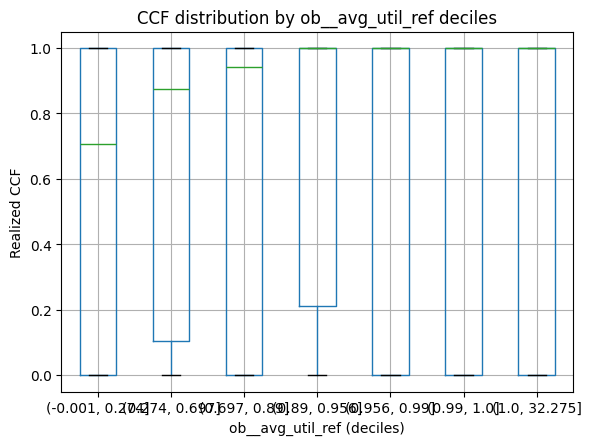

In [70]:
ccf_boxplot_by_feature(df=df,feature="ob__avg_util_ref",target="t__ccf")

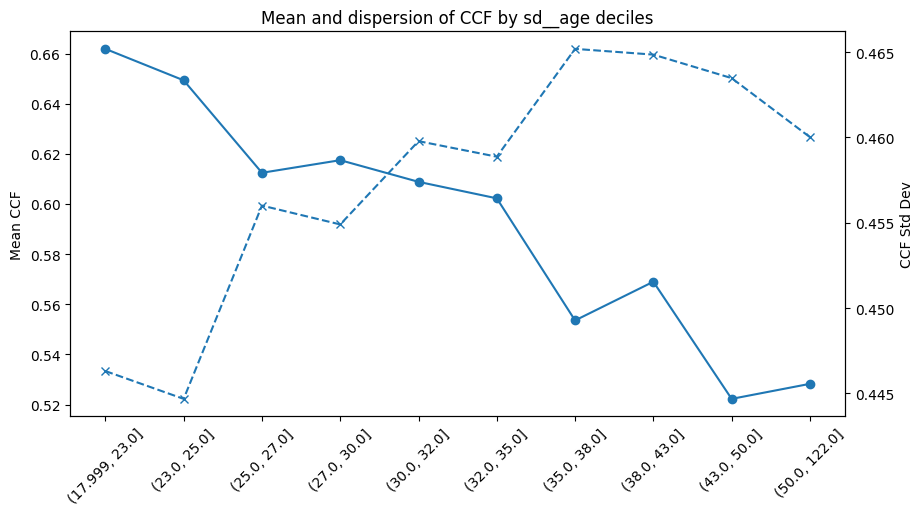

In [76]:
def ccf_mean_variance(df, feature, target, bins=10):
    tmp = df[[feature, target]].dropna()
    tmp["bin"] = pd.qcut(tmp[feature], bins, duplicates="drop")

    stats = tmp.groupby("bin")[target].agg(["mean", "std", "count"])

    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(stats.index.astype(str), stats["mean"], marker="o")
    ax1.set_ylabel("Mean CCF")

    ax2 = ax1.twinx()
    ax2.plot(stats.index.astype(str), stats["std"], marker="x", linestyle="--")
    ax2.set_ylabel("CCF Std Dev")

    plt.title(f"Mean and dispersion of CCF by {feature} deciles")
    ax1.set_xticklabels(stats.index.astype(str), rotation=45)
    plt.show()

ccf_mean_variance(df=df,feature="sd__age",target="t__ccf")

In [97]:
def error_by_feature(df, feature, target, prediction, bins=10):
    tmp = df[[feature, target, prediction]].dropna()
    tmp["bin"] = pd.qcut(tmp[feature], bins, duplicates="drop")

    return tmp.groupby("bin").apply(
        lambda x: pd.Series({
            "mean_ccf": x[target].mean(),
            "mean_pred": x[prediction].mean(),
            "mae": (x[target] - x[prediction]).abs().mean(),
            "rmse": np.sqrt(((x[target] - x[prediction])**2).mean()),
            "n_obs": len(x)
        })
    )

error_by_feature(df=df_val_fa, feature="ob__avg_util_ref", target="y_true", prediction="y_pred", bins=10)

,mean_ccf,mean_pred,mae,rmse,n_obs
bin,,,,,
"(-0.001, 0.37]",0.527442,0.763816,0.392252,0.490989,548.0
"(0.37, 0.747]",0.660016,0.823113,0.329445,0.443944,137.0
"(0.747, 0.917]",0.619901,0.877523,0.377241,0.519130,136.0
"(0.917, 0.967]",0.726063,0.946354,0.288135,0.481251,137.0
"(0.967, 0.992]",0.621130,0.957423,0.373847,0.569938,137.0
"(0.992, 1.0]",0.577631,0.974168,0.421608,0.626237,138.0
"(1.0, 3.058]",0.595588,0.987461,0.403501,0.625181,136.0


In [85]:
X_train, X_val, y_train_reg, y_val_reg = train_test_split(X, y_reg, test_size=0.1, random_state=42)
_, _, y_train_clf, y_val_clf = train_test_split(X, y_clf, test_size=0.1, random_state=42)

In [86]:
df['t__ccf'].min()

np.float64(0.0)

In [87]:
X_train_reg = X_train[reg_feats]
X_val_reg = X_val[reg_feats]

X_train_reg = X_train_reg[X_train_reg['t__ccf'] > 0]
y_train_reg = y_train_reg[y_train_reg > 0]

X_train_reg = X_train_reg.drop(columns=['t__ccf'])
X_val_reg = X_val_reg.drop(columns=['t__ccf'])

X_train_clf = X_train[clf_feats]
X_val_clf = X_val[clf_feats]

In [33]:
df_val_fa = df.loc[
    X_val_clf.index, 
    list(X_val_clf.columns) + ['user_id', 'reference_date', 'default_date']
]

In [34]:
df

,user_id,reference_date,default_date,ob__limit_ref,ob__balance_ref,ob__avg_util_ref,ob__open_limit_ref,t__is_drawn,t__ccf,mv__is_lisbon_v1,mv__is_lisbon_v2,mv__is_lisbon_v3,mv__is_lisbon_v4,mv__is_porto_v1,mv__is_porto_v2,ef__is_covid,gender,nationality,sd__age,sd__age_since_first_kyc,sd__age_since_last_kyc,sd__membership_product,sd__max_daily_logins_6m,sd__max_daily_logins_12m,madrid__avg_monthly_salary_3m,madrid__avg_monthly_expenses_3m,madrid__avg_monthly_repayment_capacity_3m,ul__is_expat,od__history_length_days,od__is_history,ob__avg_util_3m,ob__avg_util_change_3m,ob__max_util_3m,ob__max_util_change_3m,ob__std_util_3m,ob__std_util_change_3m,ob__util_slope_3m,ob__util_range_3m,ob__num_od_entries_6m,ob__num_od_exits_6m,ob__overlimit_days_6m,ob__full_repayment_events_6m,ob__max_consecutive_od_days_since_creation_ratio,ob__od_draw_days_6m,ob__od_enabled_zero_util_days_6m,ob__technical_od_days_6m,ob__technical_od_deep_days_6m,ob__avg_util_first_2m_since_creation,ob__avg_util_change_last2m_to_first2m,ob__avg_util_first2m_1y,ob__avg_util_change_last2m_to_first2m_1y,ob__max_consecutive_overlimit_days_since_creation_ratio,ob__partial_repayment_events_6m,ob__full_repayment_change_3m_vs_prev_3m,ob__util_last2m_to_first2m_ratio,ob__util_last2m_to_first2m_1y_ratio,ob__max_to_avg_util_3m_ratio,ab__avg_bal_3m,ab__avg_bal_change_3m,ab__max_util_3m,ab__max_bal_change_3m,ab__std_util_3m,ab__std_bal_change_3m,ab__bal_changed_3m,ab__bal_change_freq_3m,ab__mean_abs_change_6m,ab__std_abs_change_6m,ab__max_one_day_drop_6m,ab__inflow_spike_count_6m,ab__days_down_6m,ab__near_zero_days_6m,dn__recent_action,dn__max_action_level,cb__most_recent_score,cb__worst_score,ep__cc_tbil_balance,mix__sd_od_history_to_kyc_ratio
0,e71e8a98-7408-4a0a-9ffb-aa634d49e6a9,2023-08-21,2024-08-20,6000.0,5998.78,0.99980,0.00020,1,1.00000,1,0,0,0,0,0,0,MALE,AUT,40,2017.0,2017.0,1.0,30.0,30.0,0.00,0.000000,1169.000000,0,2018,1,1.007732,0.015231,1.029796,0.030621,0.022957,-0.014908,2.739301e-09,0.188728,0,0,56,0,0.0,181,0,0,0,0.739344,0.275498,1.006010,0.008832,0.0,6,0,1.3726,1.0087,1.0218,-6046.395604,-91.389398,-5046.41,-952.37,137.744446,-8.944555e+01,1,4,56.875083,348.784107,-3384.51,3,6,0,1.0,90.0,D,3.0,0.0,1.000496
1,e928e2e6-531b-4e23-928e-613c8d622dfd,2024-07-30,2025-07-30,250.0,0.00,0.00000,1.00000,1,0.14040,0,0,0,0,1,0,0,FEMALE,POL,45,150.0,150.0,1.0,7.0,7.0,0.00,0.000000,10.000000,1,136,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2,2,9,2,0.0,19,117,0,0,0.234047,-0.234047,NaN,NaN,0.0,0,-2,0.0000,NaN,NaN,2.112198,-0.610000,2.32,-0.61,0.290700,4.689331e-16,1,1,17.201000,90.570267,-590.49,3,6,124,10.0,10.0,C,2.0,0.0,0.906667
2,eaaee9d7-3aea-4a4c-aaa3-65c2c1b4191f,2022-12-07,2023-12-07,500.0,0.00,0.00000,1.00000,1,1.00000,1,0,0,0,0,0,0,MALE,DEU,27,2224.0,2224.0,2.0,7.0,7.0,0.00,607.000000,1881.333333,0,2225,1,0.163381,-0.479873,0.729000,-0.713720,0.299839,-0.341119,-7.610887e-08,0.729000,3,4,0,4,0.0,46,135,0,0,0.000000,0.006275,0.433903,-0.427628,0.0,1,2,NaN,0.0144,4.4619,232.568022,1059.584624,3492.36,3412.86,904.980947,1.130881e+03,1,20,57.020552,356.241185,-3063.00,5,19,46,NaN,NaN,E,4.0,0.0,1.000450
3,ed03a294-1ebb-473b-97e8-5a0abab56b8d,2018-11-27,2019-03-19,250.0,0.00,0.00000,1.00000,0,0.00000,1,0,0,0,0,0,0,MALE,DEU,29,505.0,505.0,5.0,12.0,19.0,10311.25,25706.363333,24658.186667,0,1,1,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000,0,0,0,0,NaN,0,1,0,0,0.000000,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,1139.883626,656.021624,4717.45,2087.02,1105.999238,7.997399e+02,1,69,529.733204,912.332390,-3813.61,40,84,1,NaN,NaN,G,7.0,0.0,0.001980
4,f0560a88-6dbd-4c5c-965d-9c6dc11ab2a0,2022-02-08,2022-02-15,500.0,0.00,0.00000,1.00000,1,0.26204,1,0,0,0,0,0,0,MALE,USA,25,111.0,111.0,1.0,2.0,2.0,0.00,43.046667,88.163333,1,1,1,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000,0,0,0,0,NaN,0,1,0,0,0.000000,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,62.708022,75.536720,172.30,121.21,53.587515,5.436521e+01,1,24,6.938919,19.735941,-61.58,0,21,42,Na

In [35]:
reg_xgb = XGBRegressor(
    eval_metric='mae', # Evaluate on Mean Absolute Error
    random_state=42,
    n_estimators=1500
    # Fixed initial learning rate for faster search
)

In [16]:
param_dist_logit = {
    'objective': ['reg:squarederror'],

    # Tree complexity
    'max_depth': randint(3, 10),
    'min_child_weight': randint(1, 20),
    'gamma': uniform(0.0, 0.3),

    # Sampling
    'subsample': uniform(0.6, 0.9),
    'colsample_bytree': uniform(0.6, 1.0),

    # Regularization
    'reg_alpha': uniform(0.0, 0.5),
    'reg_lambda': uniform(0.5, 2.0),

    # Learning rate
    'eta': uniform(0.01, 0.2),

    # Stability (important for skewed targets)
    'max_delta_step': randint(0, 5)
}

In [17]:
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

random_search_reg = RandomizedSearchCV(
    estimator=reg_xgb,
    param_distributions=param_dist_logit,
    n_iter=500, # A decent number of iterations for randomized search
    scoring=mae_scorer,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the search to the regression data
random_search_reg.fit(X_train_reg, y_train_reg)

print("Best MAE for Regression:", -random_search_reg.best_score_)
print("Best Params for Regression:", random_search_reg.best_params_)
best_reg_model = random_search_reg.best_estimator_

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV] END colsample_bytree=0.9745401188473625, eta=0.20014286128198325, gamma=0.21959818254342153, max_delta_step=4, max_depth=7, min_child_weight=7, objective=reg:squarederror, reg_alpha=0.22291637642679557, reg_lambda=0.6999498316360058, subsample=1.0133240027692805; total time=   0.0s
[CV] END colsample_bytree=0.9745401188473625, eta=0.20014286128198325, gamma=0.21959818254342153, max_delta_step=4, max_depth=7, min_child_weight=7, objective=reg:squarederror, reg_alpha=0.22291637642679557, reg_lambda=0.6999498316360058, subsample=1.0133240027692805; total time=   0.0s
[CV] END colsample_bytree=0.9745401188473625, eta=0.20014286128198325, gamma=0.21959818254342153, max_delta_step=4, max_depth=7, min_child_weight=7, objective=reg:squarederror, reg_alpha=0.22291637642679557, reg_lambda=0.6999498316360058, subsample=1.0133240027692805; total time=   0.0s
[CV] END colsample_bytree=0.9745401188473625, eta=0.20014286128198325, g

Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x127e07260>>
Traceback (most recent call last):
  File "/Users/ilya.katliarou/Documents/CCF/venv/lib/python3.12/site-packages/xgboost/core.py", line 630, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument

KeyboardInterrupt: 


KeyboardInterrupt: 

In [62]:
# Best parameters from your Randomized Search
best_reg_params = {
    'colsample_bytree': 0.8926127274234653,
    'eta': 0.07446666236009472,
    'gamma': 0.13139932436866622,
    'max_delta_step': 0,
    'max_depth': 8,
    'min_child_weight': 19,
    'objective': 'reg:squarederror',  # The best objective found (standard MSE)
    'quantile_alpha': 0.5,
    'reg_alpha': 0.4972155012713817,
    'reg_lambda': 0.5766149336793227,
    'subsample': 0.7460453153031672,
}

# 1. Instantiate the final regressor model
# We remove the unused 'tweedie_variance_power' for a cleaner instantiation,
# but it would not cause an error if left in.

best_reg_model = XGBRegressor(
    eval_metric='mae',
    n_estimators=1500,
    **best_reg_params
)

# 2. Fit the model to your entire training data where CCF > 0 (X_reg_train, y_reg_train)
best_reg_model.fit(X_train_reg, y_train_reg)

print("Best Regression Model Instantiated and Ready for Fitting.")

Best Regression Model Instantiated and Ready for Fitting.


In [292]:
best_reg_model.save_model("xgb_reg_ccf.json")

In [88]:
best_reg_model = XGBRegressor()
best_reg_model.load_model("xgb_reg_ccf.json")

In [89]:
y_pred_reg = best_reg_model.predict(X_val_reg)

In [93]:
y_pred_reg = best_reg_model.predict(X_val_reg)
mse = mean_squared_error(y_val_reg, y_pred_reg)
print("MSE:", mse)

MSE: 0.27703844154579854


In [92]:
y_pred_reg.shape

(1369,)

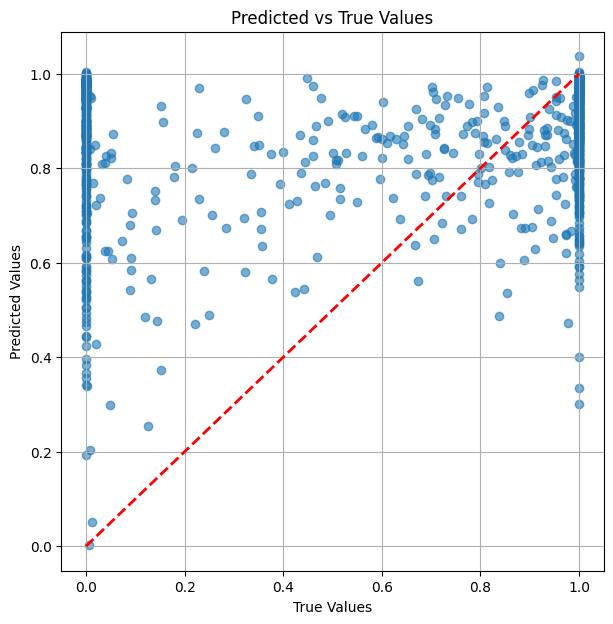

In [126]:
plt.figure(figsize=(7,7))
plt.scatter(y_val_reg, y_pred_reg, alpha=0.6)
plt.plot([y_val_reg.min(), y_val_reg.max()],
         [y_val_reg.min(), y_val_reg.max()],
         color='red', linewidth=2, linestyle='--')  # y=x reference line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.grid(True)
plt.show()

In [94]:
df_val_fa = df_val_fa.assign(
    y_true=y_val_reg,
    y_pred=y_pred_reg
)

In [95]:
df_val_fa.iloc[29,:]

ob__open_limit_ref                                                            0.0
ob__avg_util_ref                                                          1.03066
ob__limit_ref                                                              2900.0
madrid__avg_monthly_salary_3m                                                 0.0
ul__is_expat                                                                    1
ob__od_enabled_zero_util_days_6m                                                0
madrid__avg_monthly_expenses_3m                                             59.78
sd__age                                                                        31
ob__max_to_avg_util_3m_ratio                                               1.0359
ob__max_util_change_3m                                                   0.032193
sd__max_daily_logins_6m                                                       3.0
ab__avg_bal_3m                                                       -2885.263077
cb__worst_score 

In [22]:
explainer = shap.TreeExplainer(best_clf_model)

In [23]:
df_val_fa_q = df_val_fa.drop(['user_id', 'reference_date','default_date'], axis=1)

In [14]:
pos = (y_train_clf==1).sum()
neg = (y_train_clf==0).sum()
imbalance_ratio = neg/pos  # Or use a slightly wider range around this.

# 2. Define the Base Classifier
# Use binary:logistic objective for probability prediction
clf_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_estimators=1500,
    learning_rate=0.01, # Fixed initial learning rate for faster search
)

In [15]:
param_dist_clf = {
    'max_depth': randint(2, 6), # Increased upper bound
    'min_child_weight': randint(1, 7), # Increased upper bound
    'gamma': uniform(0.0, 0.2),
    'subsample': uniform(0.6, 0.9), 
    'colsample_bytree': uniform(0.3, 0.6),
    'reg_alpha': uniform(0.0, 0.3), # Switched to continuous uniform
    'reg_lambda': uniform(0.0, 0.4), # Switched to continuous uniform
    # Focus around previous best of 3.0
    'scale_pos_weight': [0.0, 0.5, 1.0, 1.5, 2.0] 
}

In [16]:
# Use StratifiedKFold for cross-validation on imbalanced data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Instantiate the search
random_search_clf = RandomizedSearchCV(
    estimator=clf_xgb,
    param_distributions=param_dist_clf,
    n_iter=100, # Number of parameter settings that are sampled
    scoring='roc_auc',
    cv=skf,
    verbose=2,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Fit the search to the classification data
#X_train, y_train_class are your training features and binary target
random_search_clf.fit(X_train_clf, y_train_clf)

print("Best AUC for Classification:", random_search_clf.best_score_)
print("Best Params for Classification:", random_search_clf.best_params_)
best_clf_model = random_search_clf.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END colsample_bytree=0.5247240713084175, gamma=0.19014286128198324, max_depth=4, min_child_weight=5, reg_alpha=0.1790550473839461, reg_lambda=0.17833310114143647, scale_pos_weight=1.0, subsample=1.0133240027692805; total time=   0.0s
[CV] END colsample_bytree=0.5247240713084175, gamma=0.19014286128198324, max_depth=4, min_child_weight=5, reg_alpha=0.1790550473839461, reg_lambda=0.17833310114143647, scale_pos_weight=1.0, subsample=1.0133240027692805; total time=   0.0s
[CV] END colsample_bytree=0.5247240713084175, gamma=0.19014286128198324, max_depth=4, min_child_weight=5, reg_alpha=0.1790550473839461, reg_lambda=0.17833310114143647, scale_pos_weight=1.0, subsample=1.0133240027692805; total time=   0.0s
[CV] END colsample_bytree=0.5247240713084175, gamma=0.19014286128198324, max_depth=4, min_child_weight=5, reg_alpha=0.1790550473839461, reg_lambda=0.17833310114143647, scale_pos_weight=1.0, subsample=1.0133240027692805; 

In [628]:
# Your optimized parameters
best_clf_params = {
    'colsample_bytree': 0.8677586958018493,
    'gamma': 0.14667230294641873,
    'max_depth': 3,
    'min_child_weight': 6,
    'reg_alpha': 0.19358332659706887,
    'reg_lambda': 0.33069105935851284,
    'scale_pos_weight': 0.5,
    'subsample': 0.8476149816384828
}

# 1. Instantiate the final classifier model
best_clf_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=1500, # Use a high number or use early stopping
    learning_rate=0.01,
    **best_clf_params
)

# 2. Fit the model to your entire training data (X_train, y_train_class)
best_clf_model.fit(X_train_clf, y_train_clf)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8677586958018493
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [306]:
best_clf_model.save_model("xgb_clf_ccf.json")

In [18]:
y_pred_clf = best_clf_model.predict_proba(X_val_clf)[:,1]

In [19]:
# ROC-AUC (if binary classification)
roc_auc = roc_auc_score(y_val_clf, y_pred_clf)

print("ROC AUC:", roc_auc)

ROC AUC: 0.6777501581849408


In [309]:
from sklearn.metrics import precision_recall_curve, f1_score

# 1. Get probabilities on validation set
y_pred_proba = best_clf_model.predict_proba(X_val_clf)[:, 1]
y_true_class_val = y_val_clf

# 2. Calculate Precision, Recall, and Thresholds
precision, recall, thresholds = precision_recall_curve(y_true_class_val, y_pred_proba)

# 3. Find the threshold that maximizes F1-score
fscores = 2 * (precision * recall) / (precision + recall)
ix = np.argmax(fscores)
best_threshold = thresholds[ix]

print('Best Threshold=%f, F1-Score=%.3f' % (best_threshold, fscores[ix]))

Best Threshold=0.223114, F1-Score=0.821


In [333]:
best_clf_model.fit(X_train_clf, y_train_clf)

explainer = shap.TreeExplainer(best_clf_model)
shap_values = explainer.shap_values(X_train_clf)

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = (
    pd.Series(mean_abs_shap, index=X_train_clf.columns)
    .sort_values(ascending=False)
)

top_shap_clf = shap_importance.head(35).index.tolist()

In [334]:
top_shap_clf

['ob__open_limit_ref',
 'ob__avg_util_ref',
 'ob__limit_ref',
 'madrid__avg_monthly_expenses_3m',
 'ob__max_to_avg_util_3m_ratio',
 'ul__is_expat',
 'ab__avg_bal_3m',
 'sd__age',
 'madrid__avg_monthly_salary_3m',
 'ob__max_util_change_3m',
 'ob__od_enabled_zero_util_days_6m',
 'cb__worst_score',
 'sd__max_daily_logins_6m',
 'ab__inflow_spike_count_6m',
 'ab__std_abs_change_6m',
 'ab__days_down_6m',
 'ob__avg_util_3m',
 'sd__max_daily_logins_12m',
 'ab__std_bal_change_3m',
 'ob__util_last2m_to_first2m_ratio',
 'mix__sd_od_history_to_kyc_ratio',
 'madrid__avg_monthly_repayment_capacity_3m',
 'ab__near_zero_days_6m',
 'ab__max_bal_change_3m',
 'ep__cc_tbil_balance',
 'ab__bal_change_freq_3m',
 'mv__is_lisbon_v1',
 'ab__avg_bal_change_3m',
 'ab__max_one_day_drop_6m',
 'ob__partial_repayment_events_6m']

In [104]:
best_reg_model.fit(X_train_reg, y_train_reg)

explainer = shap.TreeExplainer(best_reg_model)
shap_values = explainer.shap_values(X_train_reg)

top_shap_reg = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_reg.columns)
    .sort_values(ascending=False)
    .head(35)
    .index.tolist()
)

In [105]:
top_shap_reg

['ob__limit_ref',
 'ob__max_to_avg_util_3m_ratio',
 'ob__open_limit_ref',
 'ob__avg_util_ref',
 'ob__max_util_3m',
 'ob__avg_util_3m',
 'madrid__avg_monthly_expenses_3m',
 'ob__od_enabled_zero_util_days_6m',
 'ob__partial_repayment_events_6m',
 'mix__sd_od_history_to_kyc_ratio',
 'sd__age_since_last_kyc',
 'ab__std_abs_change_6m',
 'sd__age',
 'ob__util_last2m_to_first2m_1y_ratio',
 'sd__max_daily_logins_12m',
 'ob__std_util_3m',
 'ab__bal_change_freq_3m',
 'ob__od_draw_days_6m',
 'sd__max_daily_logins_6m',
 'sd__age_since_first_kyc',
 'madrid__avg_monthly_salary_3m',
 'ab__max_one_day_drop_6m',
 'cb__worst_score',
 'mv__is_lisbon_v1',
 'ul__is_expat',
 'ab__inflow_spike_count_6m',
 'ob__util_range_3m',
 'ob__avg_util_change_last2m_to_first2m_1y',
 'madrid__avg_monthly_repayment_capacity_3m',
 'sd__membership_product',
 'ob__balance_ref',
 'ob__max_util_change_3m',
 'ob__avg_util_change_3m',
 'ob__num_od_exits_6m',
 'ob__util_last2m_to_first2m_ratio']

In [100]:
from sklearn.metrics import roc_auc_score

results = []

for k in [5, 10, 15, 20, 25, 30, 40, 60, 100]:
    feats = top_shap_clf[:k]

    model = XGBClassifier(**best_clf_params)
    model.fit(X_train_clf[feats], y_train_clf)

    preds = model.predict_proba(X_val[feats])[:, 1]
    auc = roc_auc_score(y_val_clf, preds)

    results.append((k, auc))

perf_df = pd.DataFrame(results, columns=["n_features", "auc"])

In [101]:
perf_df

,n_features,auc
0,5,0.626744
1,10,0.683303
2,15,0.687025
3,20,0.696711
4,25,0.692142
5,30,0.690374
6,40,0.711607
7,60,0.711607
8,100,0.711607


# Test Set and hurdle model

In [711]:
y_test_reg = df_test['t__ccf'].clip(upper=2.0)
y_test_clf = df_test['t__is_drawn']

In [712]:
X_test_reg = df_test[reg_feats]
X_test_reg = X_test_reg.drop(columns=['t__ccf'])
X_test_clf = df_test[clf_feats]

In [694]:
X_test_clf

,ob__open_limit_ref,ob__avg_util_ref,ob__limit_ref,madrid__avg_monthly_salary_3m,ul__is_expat,ob__od_enabled_zero_util_days_6m,madrid__avg_monthly_expenses_3m,sd__age,ob__max_to_avg_util_3m_ratio,ob__max_util_change_3m,sd__max_daily_logins_6m,ab__avg_bal_3m,cb__worst_score,mix__sd_od_history_to_kyc_ratio,ab__days_down_6m,ab__inflow_spike_count_6m,sd__max_daily_logins_12m,ab__std_abs_change_6m,ab__std_bal_change_3m,ab__near_zero_days_6m,ab__bal_change_freq_3m,ep__cc_tbil_balance,madrid__avg_monthly_repayment_capacity_3m,ab__max_bal_change_3m,ob__util_last2m_to_first2m_ratio,ab__avg_bal_change_3m,ob__avg_util_3m,ab__max_one_day_drop_6m,mv__is_lisbon_v1,ob__partial_repayment_events_6m
13519,1.00000,0.00000,10000.0,0.053333,0,179,695.590000,32,97.0000,-0.000194,14.0,4347.152967,2.0,1.000712,103,8,14.0,134.453791,656.130494,0,56,0.00,1284.480000,-183.58,NaN,-1308.265183,0.000002,-570.00,1,0
14889,0.07857,0.92143,3750.0,0.000000,1,0,131.666667,39,1.1169,-0.020008,4.0,-3160.845604,7.0,0.337979,44,4,7.0,101.911154,204.987625,0,25,0.00,613.730000,588.44,7.1744,387.114753,0.842891,-350.00,1,6
13064,0.08650,0.91350,500.0,2100.580000,1,48,1175.390000,37,1.5334,-0.034740,5.0,-23.786923,5.0,0.553819,74,7,7.0,366.399796,103.764485,4,44,342.12,1285.413333,7.72,1.2485,225.050527,0.672099,-1323.15,1,7
4625,0.00000,1.02027,10000.0,0.000000,1,0,1297.656667,37,1.0377,0.022174,1.0,-9831.622967,9.0,0.594033,38,9,3.0,212.077842,-75.033927,0,25,0.00,1161.263333,34.02,133.8432,-335.304763,0.983162,-740.00,1,13
387,0.08251,0.91749,10000.0,165.000000,0,0,691.706667,23,1.1373,-0.018510,10.0,-8517.128791,7.0,0.996403,89,39,10.0,484.754886,-374.928886,0,71,934.71,6673.743333,-1471.68,7.8795,47.774806,0.865559,-2232.72,1,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326,0.77780,0.22220,250.0,1509.940000,0,0,502.510000,34,1.0000,NaN,4.0,327.192857,4.0,0.037037,10,1,4.0,295.716795,NaN,15,11,0.00,1052.400000,NaN,1.0000,NaN,0.222200,-349.54,1,0
8424,0.00001,0.99999,2000.0,264.740000,0,0,1300.753333,26,1.1053,0.001005,26.0,-1848.622308,7.0,0.934013,56,8,26.0,122.206076,-230.215949,0,47,0.00,1824.013333,-771.89,1.0741,-208.854409,0.924311,-741.70,1,27
5250,0.36259,0.63741,6000.0,617.400000,0,20,4172.963333,31,2.2549,0.969916,6.0,-1475.280110,7.0,0.462857,111,19,6.0,998.109195,-269.181465,3,79,336.35,4796.650000,-5327.45,1.5443,-6460.250753,0.430137,-2933.53,1,6
7580,0.17210,0.82790,500.0,NaN,0,3,NaN,24,1.2987,0.029260,6.0,-391.383187,5.0,0.452412,36,2,6.0,66.878263,-56.007302,0,24,0.00,NaN,-76.30,0.8865,70.869548,0.782766,-276.00,1,9


In [590]:
threshold = 0.258936

def predict_ccf(X_clf, X_reg, best_clf_model, best_reg_model, threshold, upper_clipping_limit=2.0, bottom_clipping_limit=0.0):
    """
    Applies the Hurdle Model logic to predict CCF for new data.
    """
    # 1. Classification (The Hurdle)
    clf_probabilities = best_clf_model.predict_proba(X_clf)[:, 1]
    predicted_ccf = np.zeros(X_clf.shape[0])
    non_zero_indices = clf_probabilities >= threshold
    
    if np.any(non_zero_indices):
        # 2. Regression (The Value)
        X_reg_input = X_reg[non_zero_indices]
        reg_predictions = best_reg_model.predict(X_reg_input)
        
        # 3. Clipping (The Constraint)
        final_values = np.clip(reg_predictions, a_min=bottom_clipping_limit, a_max=upper_clipping_limit)
        
        # 4. Final Output Assembly
        predicted_ccf[non_zero_indices] = final_values
        
    return predicted_ccf

In [598]:
final_predictions = predict_ccf(X_clf=X_test_clf,
                                X_reg=X_test_reg,
                                           best_clf_model=best_clf_model,
                                           best_reg_model=best_reg_model,
                                           threshold=0.5,
                                           bottom_clipping_limit=0.0,
                                           upper_clipping_limit=2.0)

In [713]:
y_pred_test_clf = best_clf_model.predict_proba(X_test_clf)[:,1]
y_pred_test_reg = best_reg_model.predict(X_test_reg)

In [714]:
y_pred = y_pred_test_clf*np.clip(a=y_pred_test_reg, a_min=0.0, a_max=2.0)
mse = mean_squared_error(y_test_reg, y_pred)
print("MSE:", mse)

MSE: 0.30635222535953593


In [716]:
y_test_reg.mean()

np.float64(0.6774001481004508)

In [715]:
y_pred.mean()

np.float32(0.5402649)

In [599]:
final_predictions.max()

np.float64(1.3176630735397339)

In [600]:
mse = mean_squared_error(y_test_reg, final_predictions)
print("MSE:", mse)

MSE: 37.646194800222005


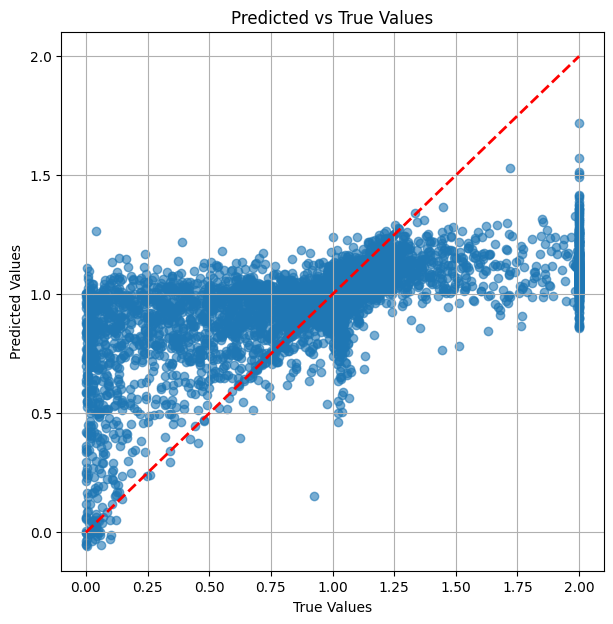

In [644]:
plt.figure(figsize=(7,7))
plt.scatter(y_train_reg, y_pred_test_reg, alpha=0.6)
plt.plot([y_train_reg.min(), y_train_reg.max()],
         [y_train_reg.min(), y_train_reg.max()],
         color='red', linewidth=2, linestyle='--')  # y=x reference line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.grid(True)
plt.show()

In [642]:
from sklearn.metrics import mean_squared_error, r2_score
rmse = mean_squared_error(y_test_reg,y_pred)
r2 = r2_score(y_test_reg, y_pred)
print(f"RMSE: {rmse}, R²: {r2}")

RMSE: 0.30635222535953593, R²: 0.061845335414291824


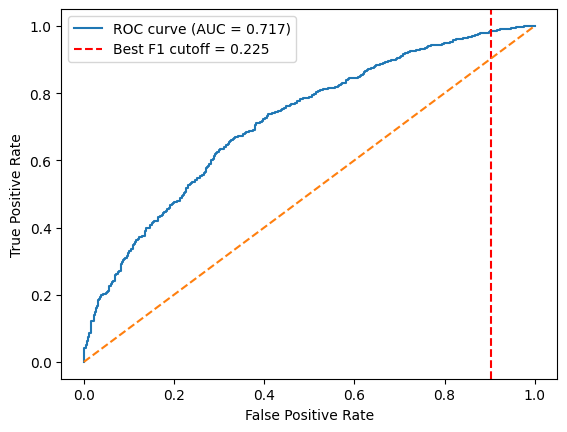

In [501]:
from sklearn.metrics import roc_curve, roc_auc_score, f1_score

# Predicted probabilities
y_score = best_clf_model.predict_proba(X_test_clf)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test_clf, y_score)
auc = roc_auc_score(y_test_clf, y_score)

# ---- F1 optimization ----
f1_scores = []
for thr in thresholds:
    y_pred = (y_score >= thr).astype(int)
    f1_scores.append(f1_score(y_test_clf, y_pred))

f1_scores = np.array(f1_scores)
best_f1_idx = np.argmax(f1_scores)
best_f1_cutoff = thresholds[best_f1_idx]

# ---- Plot ----
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")

# Highlight F1-optimal cutoff
plt.axvline(
    fpr[best_f1_idx],
    linestyle="--",
    color="red",
    label=f"Best F1 cutoff = {best_f1_cutoff:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

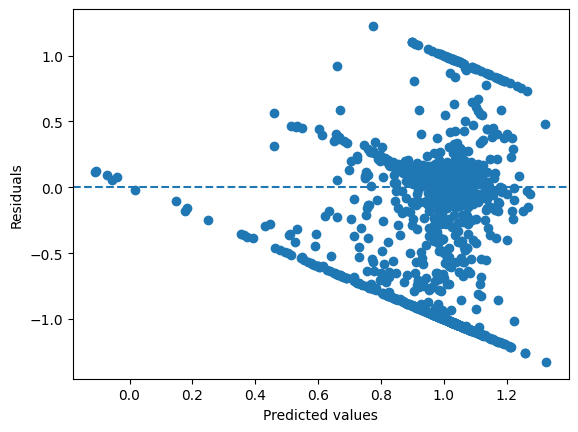

In [645]:
# Predictions
y_pred = best_reg_model.predict(X_test_reg)

# Residuals
residuals = y_test_reg - y_pred

# Plot
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()